---
Author: The Tuan Trinh \
Date: 01/06/2026
---

In [1]:
import os
import platform
print("=" * 100)
print("OS Name:", os.name)
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Platform:", platform.platform())

print("\nEnvironment Variables (sample):")
for key, value in list(os.environ.items())[:15]:
    print(f"{key} = {value}")

OS Name: nt
System: Windows
Release: 10
Machine: AMD64
Processor: Intel64 Family 6 Model 142 Stepping 12, GenuineIntel
Platform: Windows-10-10.0.26200-SP0

Environment Variables (sample):
ALLUSERSPROFILE = C:\ProgramData
APPDATA = C:\Users\Admin\AppData\Roaming
APPLICATION_INSIGHTS_NO_STATSBEAT = true
CHROME_CRASHPAD_PIPE_NAME = \\.\pipe\crashpad_9744_ZGSXKUMXDBQNQZJY
COMMONPROGRAMFILES = C:\Program Files\Common Files
COMMONPROGRAMFILES(X86) = C:\Program Files (x86)\Common Files
COMMONPROGRAMW6432 = C:\Program Files\Common Files
COMPUTERNAME = PMH
COMSPEC = C:\Windows\system32\cmd.exe
CONDA_DEFAULT_ENV = PMH
CONDA_EXE = C:\Users\Admin\miniconda3\Scripts\conda.exe
CONDA_PREFIX = C:\Users\Admin\miniconda3\envs\PMH
CONDA_PROMPT_MODIFIER = (PMH) 
CONDA_PYTHON_EXE = C:\Users\Admin\miniconda3\python.exe
CONDA_ROOT = C:\Users\Admin\miniconda3


In [2]:
platform.python_version()

'3.10.20'

# Lab 11 - Image Segmentation with Watershed Algorithm

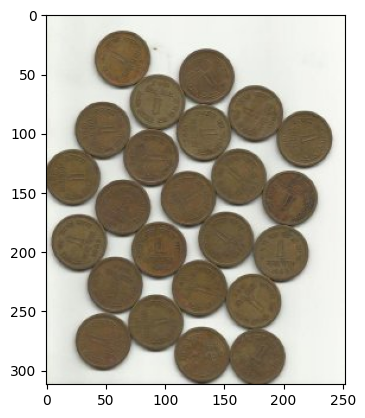

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
 
img = cv.imread('D:\MASTER\EEE803145 - IP\LAB\LAB11\water_coins.jpg')
img_rgb = cv.cvtColor(img,cv.COLOR_BGR2RGB)
plt.imshow(img_rgb)
assert img is not None, "file could not be read, check with os.path.exists()"

(np.float64(-0.5), np.float64(251.5), np.float64(311.5), np.float64(-0.5))

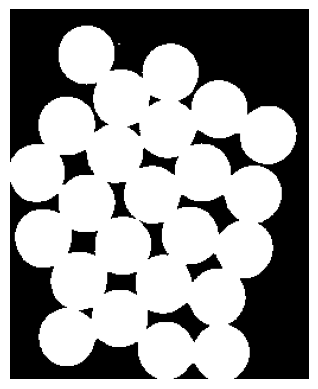

In [3]:
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray,0,255,cv.THRESH_BINARY_INV+cv.THRESH_OTSU)
plt.imshow(thresh, cmap='gray')
plt.axis("off")

(np.float64(-0.5), np.float64(251.5), np.float64(311.5), np.float64(-0.5))

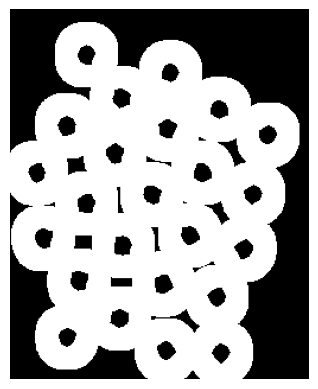

In [5]:
# noise removal
kernel = np.ones((3,3),np.uint8)
opening = cv.morphologyEx(thresh,cv.MORPH_OPEN,kernel, iterations = 2)
 
# sure background area
sure_bg = cv.dilate(opening,kernel,iterations=3)
 
# Finding sure foreground area
dist_transform = cv.distanceTransform(opening,cv.DIST_L2,5)
ret, sure_fg = cv.threshold(dist_transform,0.7*dist_transform.max(),255,0)
 
# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv.subtract(sure_bg,sure_fg)
plt.imshow(unknown, cmap='gray')
plt.axis("off")

(np.float64(-0.5), np.float64(251.5), np.float64(311.5), np.float64(-0.5))

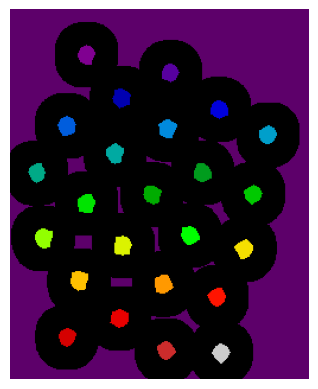

In [6]:
# Marker labelling
ret, markers = cv.connectedComponents(sure_fg)
 
# Add one to all labels so that sure background is not 0, but 1
markers = markers+1
 
# Now, mark the region of unknown with zero
markers[unknown==255] = 0

plt.imshow(markers, cmap='nipy_spectral')
plt.axis("off")

(np.float64(-0.5), np.float64(251.5), np.float64(311.5), np.float64(-0.5))

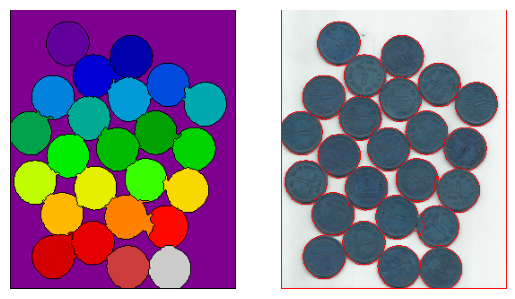

In [9]:
markers = cv.watershed(img,markers)
img[markers == -1] = [255,0,0]

# plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)    
plt.imshow(markers, cmap='nipy_spectral')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img)
plt.axis("off")